In [1]:
import pandas as pd
import numpy as np
from termcolor import colored
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sns.set_style("darkgrid")

# Load correct dataset (536 games)
df_games = pd.read_csv('../data/games_preprocessed.csv')
df_games['processed_description'] = df_games['processed_description'].fillna('')
print(colored(f'Documents loaded: {len(df_games)}', 'green'))
df_games.head()

Documents loaded: 536


,app_id,title,genre,url,description,rating,ratings,reviews,desc_length,processed_description,processed_tokens,processed_length
0,ai.character.app,"Character AI: Chat, Talk, Text",Entretenimiento,https://play.google.com/store/apps/details?id=...,✨Character.AI no es solo otra aplicación de co...,1.362544,2253536.0,6382.0,611,character ai aplicación conversación ia patio ...,"['character', 'ai', 'aplicación', 'conversació...",305
1,air.com.bmapps.gossipgirlsdivasinhighschool,Gossip Girls Divas Highschool,Entretenimiento,https://play.google.com/store/apps/details?id=...,Estas tres chicas de secundaria quieren ser di...,3.558442,15228.0,30.0,378,chica secundaria querer diva real horario prog...,"['chica', 'secundaria', 'querer', 'diva', 'rea...",158
2,air.com.buffalo_studios.newflashbingo,Bingo Blitz™️: juegos de Bingo,Juegos de mesa,https://play.google.com/store/apps/details?id=...,Experimenta tu juego de bingo en línea como nu...,4.429238,1417570.0,2475.0,618,experimenta bingo línea adentrar aventura jueg...,"['experimenta', 'bingo', 'línea', 'adentrar', ...",275
3,air.com.flipline.papascheeseriatogo,Papa's Cheeseria To Go!,Estrategia,https://play.google.com/store/apps/details?id=...,-- SOBRE EL JUEGO --\r\n\r\n¡Papa's Cheeseria ...,4.739130,2293.0,2.0,650,juego cheeseria inaugurar inauguración actuaci...,"['juego', 'cheeseria', 'inaugurar', 'inaugurac...",312
4,air.com.flipline.papascluckeriatogo,Papa's Cluckeria To Go!,Estrategia,https://play.google.com/store/apps/details?id=...,-- SOBRE EL JUEGO --\r\n\r\n¡La Guerra de los ...,4.772728,2122.0,9.0,638,juego guerra sándwiches pollo comenzar papa lo...,"['juego', 'guerra', 'sándwiches', 'pollo', 'co...",324


In [2]:
sentences = df_games['processed_description'].str.split().tolist()
print(colored(f'Documents: {len(sentences)}', 'green'))
print(colored(f'Sample: {sentences[0][:10]}', 'blue'))

Documents: 536
Sample: ['character', 'ai', 'aplicación', 'conversación', 'ia', 'patio', 'recreo', 'infinito', 'imaginación', 'creatividad']


In [3]:
from gensim.models import Word2Vec

In [4]:
# Domain-specific stopwords for mobile games
# Using explicit list (same as notebook 01 preprocessing pipeline)
# Statistical threshold approach (>60% docs) yields 0 results on this corpus
# because the vocabulary is too diverse across 536 games
domain_stopwords = {
    'juego', 'jugar', 'jugador', 'gratis', 'nuevo', 'app',
    'game', 'play', 'player', 'free', 'new', 'get', 'feature'
}

print(f"Domain stopwords: {len(domain_stopwords)}")
print(domain_stopwords)

# Filter sentences
sentences_filtered = [
    [word for word in sentence if word not in domain_stopwords]
    for sentence in sentences
]

# Verify filtering worked
total_removed = sum(
    len(s) - len(sf) 
    for s, sf in zip(sentences, sentences_filtered)
)
print(f"\nTokens removed by domain stopwords: {total_removed}")
print(f"Sample filtered (first doc, first 10 tokens): {sentences_filtered[0][:10]}")

Domain stopwords: 13
{'free', 'nuevo', 'jugar', 'app', 'player', 'new', 'feature', 'play', 'jugador', 'juego', 'game', 'gratis', 'get'}

Tokens removed by domain stopwords: 1421
Sample filtered (first doc, first 10 tokens): ['character', 'ai', 'aplicación', 'conversación', 'ia', 'patio', 'recreo', 'infinito', 'imaginación', 'creatividad']


In [5]:
w2v_model = Word2Vec(
    sentences=sentences_filtered,   # ← CHANGED: was sentences
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    seed=42                         # ← ADDED: for reproducibility (random_state=42 style)
)

print(colored(f"Vocabulary size: {len(w2v_model.wv)}", 'green'))
print(colored(f"Embedding dimension: {w2v_model.vector_size}", 'blue'))

Vocabulary size: 11587
Embedding dimension: 100


In [6]:
print("Vocabulary size:", len(w2v_model.wv))

Vocabulary size: 11587


In [7]:
w2v_model.wv.most_similar("acción", topn=10)

[('mundo', 0.9998708963394165),
 ('juegos', 0.9998590350151062),
 ('experiencia', 0.9998588562011719),
 ('clásico', 0.9998502135276794),
 ('aventura', 0.9998398423194885),
 ('divertido', 0.9998361468315125),
 ('explorar', 0.9998252987861633),
 ('características', 0.9998173713684082),
 ('creer', 0.9998165965080261),
 ('emocionante', 0.9998140335083008)]

In [8]:
w2v_model.wv.most_similar("puzzle", topn=10)

[('características', 0.9997760653495789),
 ('juegos', 0.9997522234916687),
 ('mundo', 0.9997274875640869),
 ('aventura', 0.9997228980064392),
 ('personaje', 0.9997171759605408),
 ('ciudad', 0.9997155666351318),
 ('puzl', 0.9997150897979736),
 ('emocionante', 0.999713122844696),
 ('creer', 0.9997107982635498),
 ('descubrir', 0.9997101426124573)]

In [9]:
w2v_model.wv.most_similar("carrera", topn=10)

[('mundo', 0.9998589754104614),
 ('emocionante', 0.9998297095298767),
 ('divertido', 0.9998264312744141),
 ('desafío', 0.9998202919960022),
 ('nivel', 0.999819815158844),
 ('clásico', 0.9998117685317993),
 ('aventura', 0.9998016357421875),
 ('rompecabeza', 0.9997985363006592),
 ('juegos', 0.9997979998588562),
 ('experiencia', 0.9997975826263428)]

In [10]:
from gensim import corpora, models

dictionary = corpora.Dictionary(sentences)
corpus_bow = [dictionary.doc2bow(sentence) for sentence in sentences]
tfidf_model = models.TfidfModel(corpus_bow)
corpus_tfidf = list(tfidf_model[corpus_bow])

In [11]:
import numpy as np

# Document vectorization: TF-IDF weighted average of word vectors
# Instead of simple mean, TF-IDF weights downweight generic terms
# (e.g. "nivel", "mundo") that appear across many game descriptions

def document_vector_tfidf(doc_tfidf, dictionary, model, vector_size=100):
    weighted_vectors = []
    weights = []

    for word_id, weight in doc_tfidf:
        word = dictionary[word_id]
        if word in model.wv:
            weighted_vectors.append(model.wv[word] * weight)
            weights.append(weight)

    if len(weighted_vectors) == 0:
        return np.zeros(vector_size)

    return np.sum(weighted_vectors, axis=0) / np.sum(weights)

In [12]:
doc_vectors = np.array([
    document_vector_tfidf(doc, dictionary, w2v_model, vector_size=100)
    for doc in corpus_tfidf
])

doc_vectors.shape

(536, 100)

In [13]:
doc_vectors[0][:10]

array([ 0.10333181, -0.09277771, -0.14128214,  0.00483996, -0.25867388,
        0.16042921,  0.21685626,  0.32719842, -0.0585019 , -0.02265922],
      dtype=float32)

In [14]:
import pickle

with open("../data/vectors_w2v.pkl", "wb") as f:
    pickle.dump(doc_vectors, f)

print("Word2Vec document vectors saved successfully.")

Word2Vec document vectors saved successfully.


In [15]:
import os

os.path.exists("../data/vectors_w2v.pkl")

True

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

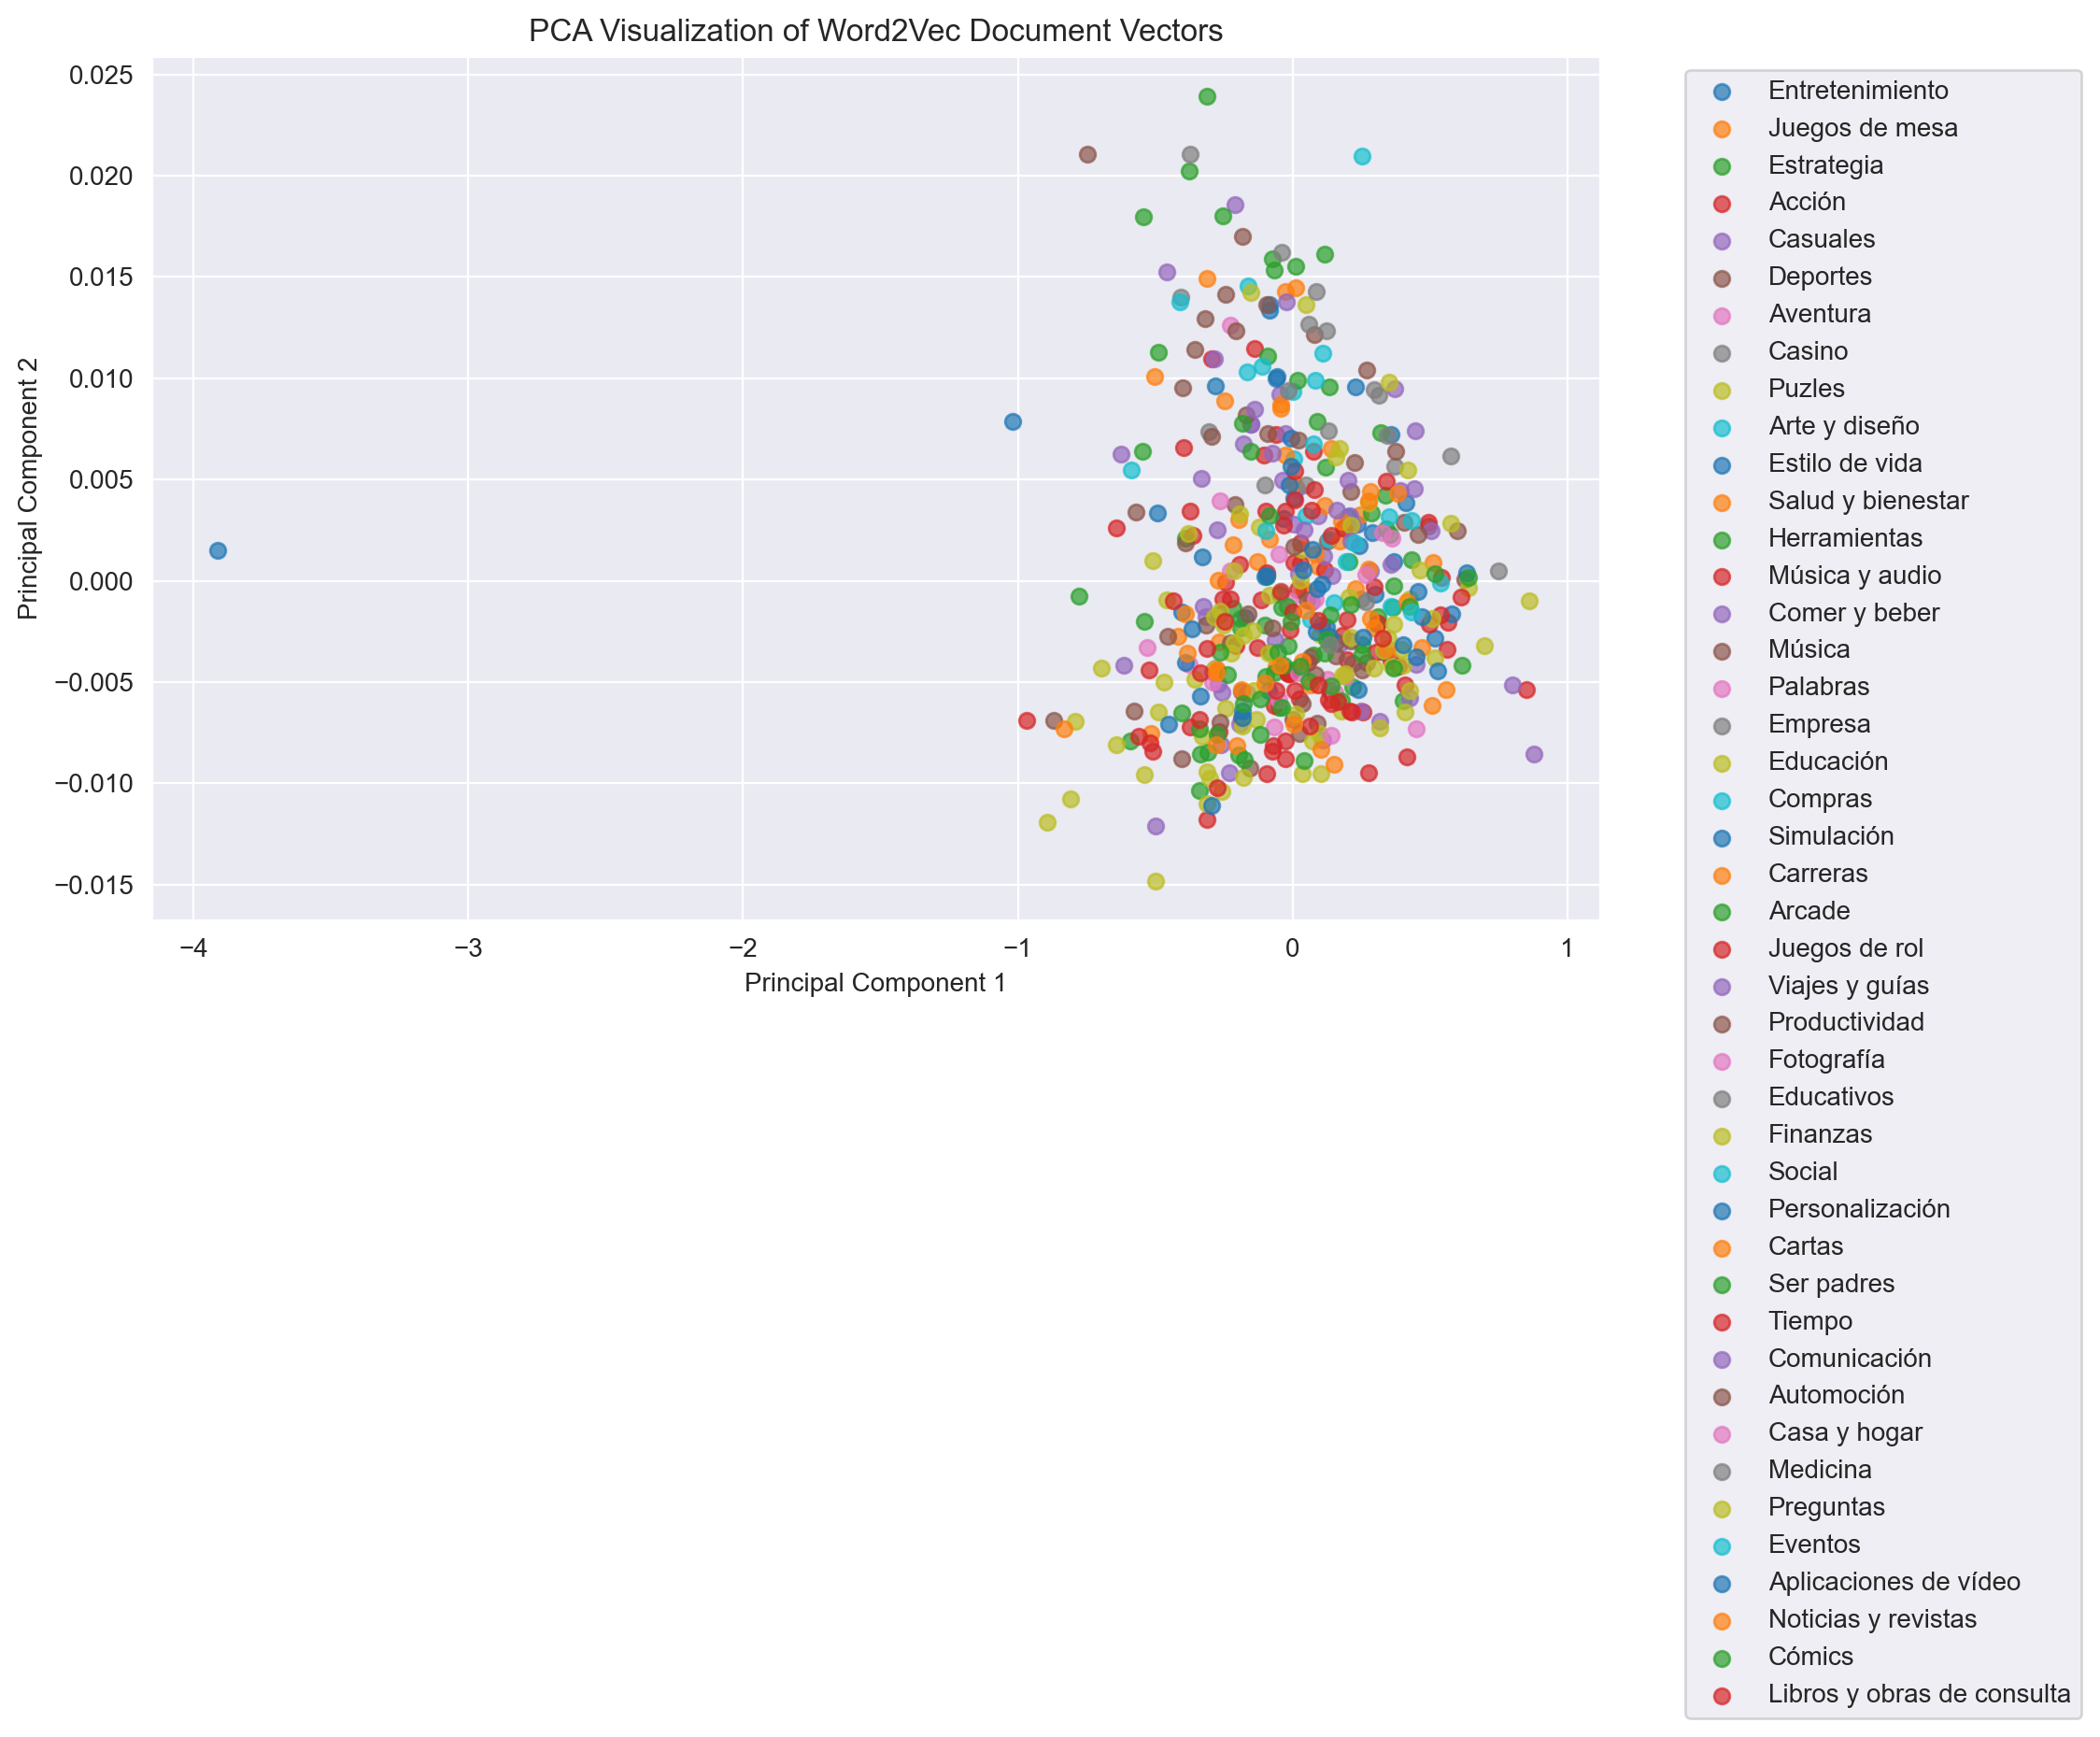

In [17]:
pca = PCA(n_components=2)
doc_vectors_2d = pca.fit_transform(doc_vectors)

plt.figure(figsize=(10, 6))

for genre in df_games["genre"].unique():
    idx = df_games["genre"] == genre
    plt.scatter(doc_vectors_2d[idx, 0], doc_vectors_2d[idx, 1], label=genre, alpha=0.7)

plt.title("PCA Visualization of Word2Vec Document Vectors")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

## Interpretation of Word2Vec Document Vectors

The PCA projection shows the 100-dimensional Word2Vec document vectors reduced to two dimensions for visualization.

Some overlap between genres is expected because many game descriptions share general gaming vocabulary. Even so, the embeddings still capture semantic structure and allow similar games to be represented with nearby vectors in the embedding space.

This representation is more context-aware than classical BoW or TF-IDF because it uses dense word embeddings and combines them into document-level vectors.

In [18]:
# Word2Vec Summary
print(colored('============= Word2Vec Embeddings Summary =============', 'blue'))
print(colored(f'Model: Word2Vec (Gensim CBOW)', 'green'))
print(colored(f'Documents embedded: {doc_vectors.shape[0]}', 'green'))
print(colored(f'Embedding dimension: {doc_vectors.shape[1]}', 'green'))
print(colored(f'Vocabulary size: {len(w2v_model.wv)}', 'green'))
print(colored(f'Document vectorization: TF-IDF weighted average of word vectors', 'blue'))
print(colored(f'Saved to: data/vectors_w2v.pkl', 'green'))
print(colored('\nKey observations:', 'blue'))
print(' - Domain stopwords (juego, play, game, etc.) removed before training')
print(' - High similarity scores (~0.999) are expected on a small corpus of 536 games')
print('   because many descriptions share general gaming vocabulary')
print(' - TF-IDF weighting downweights generic terms when averaging word vectors')
print(' - Word2Vec captures semantic relationships: accion -> enemigo, aventura, heroe')

============= Word2Vec Embeddings Summary =============
Model: Word2Vec (Gensim CBOW)
Documents embedded: 536
Embedding dimension: 100
Vocabulary size: 11587
Document vectorization: TF-IDF weighted average of word vectors
Saved to: data/vectors_w2v.pkl

Key observations:
 - Domain stopwords (juego, play, game, etc.) removed before training
 - High similarity scores (~0.999) are expected on a small corpus of 536 games
   because many descriptions share general gaming vocabulary
 - TF-IDF weighting downweights generic terms when averaging word vectors
 - Word2Vec captures semantic relationships: accion -> enemigo, aventura, heroe


## Word Similarity Analysis

The similarity queries show that Word2Vec learns contextual relationships between words that appear in similar game descriptions.

For example:
- **"acción"** is close to general gameplay and combat-related words
- **"puzzle"** is linked to words associated with objectives, strategy, and progression
- **"carrera"** is associated with competitive and gameplay-related terms

Because the dataset is relatively small and many descriptions use shared gaming vocabulary, some neighbors are generic. Even so, the model captures useful semantic patterns.